# Exploratory Data Analysis

This notebook explores the labelled data written by the data acquisition notebook. It explores class balance, per-device summary statistics, feature redundancy, benign-versus-attack separation, and a 2D projection.

In [1]:
# Standard library
import os
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Move into the repository root so config.py and every relative path inside it resolve correctly
if not Path("config.py").exists():
    os.chdir("..")

# Local
import config

# Show every column when previewing a DataFrame, instead of truncating with "..."
pd.set_option("display.max_columns", None)

## Load the processed data

The random seed is set to ensure that later sampling and the t-SNE projection are reproducible. The figure output folder does not exist yet, so it is created here. The dataframe written by the data acquisition notebook is then loaded for read-only purposes.

In [2]:
# A specific seed is set to ensure that the random parts are repeatable (subsampling, t-SNE)
np.random.seed(config.RANDOM_SEED)

# Create the figure output folder since it does not exist yet
Path(config.FIGURE_DIRECTORY).mkdir(parents=True, exist_ok=True)

# Load the cleaned, labelled, sampled dataframe written by the data acquisition notebook
df = pd.read_parquet(Path(config.PROCESSED_DIRECTORY) / "df.parquet")
feature_columns = config.feature_columns(df)
print(f"Rows: {len(df)}")
print(f"Feature columns: {len(feature_columns)}")
print(f"Total columns: {df.shape[1]}")

Rows: 419531
Feature columns: 115
Total columns: 118


## Check the class balance

Benign traffic is the only traffic the unsupervised models are allowed to train on. Hence, it is important to see exact label counts after subsampling, both overall and for each device.

label
benign    299531
gafgyt     60000
mirai      60000
Name: count, dtype: int64

label                             benign  gafgyt  mirai
device                                                 
Danmini_Doorbell                   40395   20000  20000
Philips_B120N10_Baby_Monitor      165141   20000  20000
Provision_PT_838_Security_Camera   93995   20000  20000


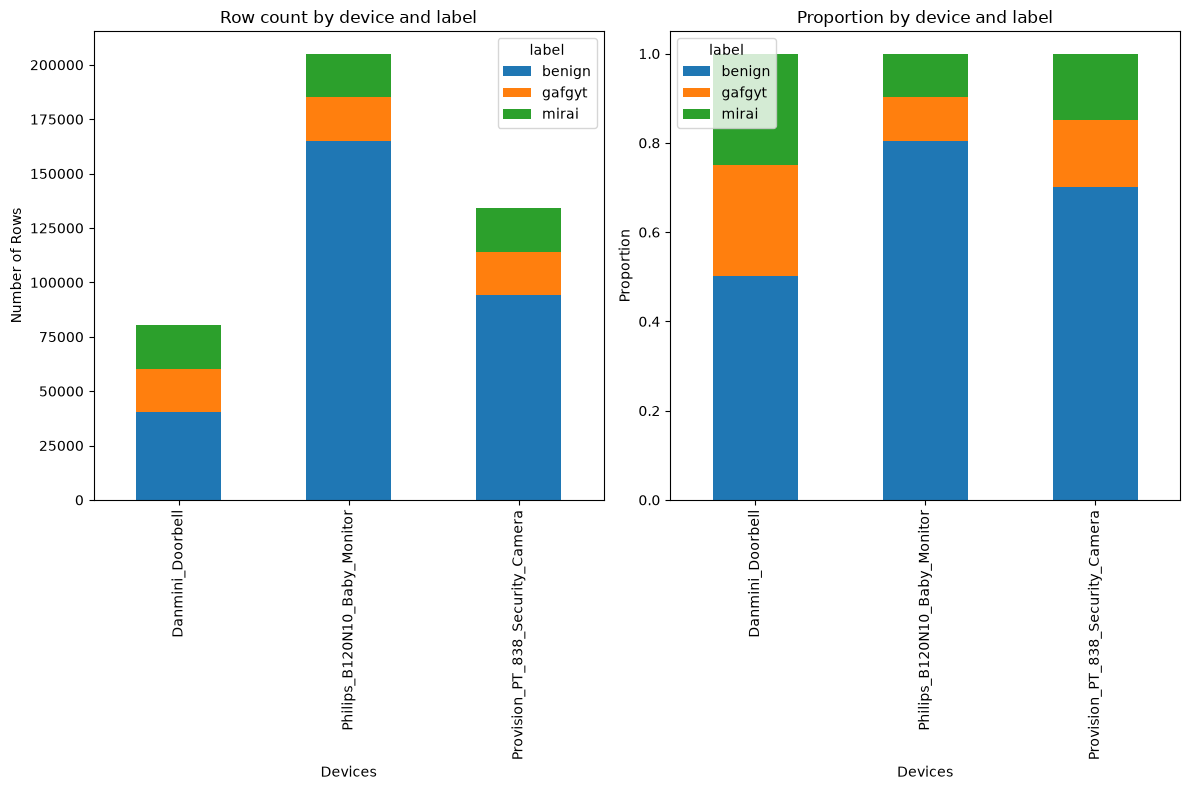

In [3]:
# Report the overall balance of benign versus attack traffic
print(df["label"].value_counts())
print()

# Report the balance of benign versus attack traffic for each device
counts_by_device_and_label = (df.groupby(["device", "label"]).size().unstack(fill_value=0).reindex(config.CHOSEN_DEVICES))
print(counts_by_device_and_label)

# Plot the raw counts and the proportions side by side
figure, axes = plt.subplots(1, 2, figsize=(12, 8))
counts_by_device_and_label.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title("Row count by device and label")
axes[0].set_ylabel("Number of Rows")
axes[0].set_xlabel("Devices")
proportions_by_device_and_label = counts_by_device_and_label.div(counts_by_device_and_label.sum(axis=1), axis=0)
proportions_by_device_and_label.plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title("Proportion by device and label")
axes[1].set_ylabel("Proportion")
axes[1].set_xlabel("Devices")
figure.tight_layout()
figure.savefig(Path(config.FIGURE_DIRECTORY) / "eda_class_balance.png")

Benign traffic is the majority class for every device, and the devices differ substantially in size. Philips has significantly more rows than Danmini or Provision. This size difference is why a pooled training set later caps how many benign rows are taken from any one device, so that a single device (such as Philips) cannot dominate the shared, pooled baseline.

## Compare per-device summary statistics

The mean, variance, and skew of every feature are computed separately for each device to see how differently each device's traffic behaves before any model is trained on it.

In [4]:
# Compute mean, variance, and skew of every feature, grouped by device
summary_statistics = df.groupby("device")[feature_columns].agg(["mean", "var", "skew"])
summary_statistics

MI_dir_L5_weight                         \
                                             mean          var      skew   
device                                                                     
Danmini_Doorbell                        49.741605  4366.333180  0.896090   
Philips_B120N10_Baby_Monitor            20.733954  2272.307992  2.380535   
Provision_PT_838_Security_Camera        29.759977  2469.343394  2.022072   

                                 MI_dir_L5_mean                         \
                                           mean          var      skew   
device                                                                   
Danmini_Doorbell                     124.441223  12074.64819  2.378591   
Philips_B120N10_Baby_Monitor          98.474920  14894.50341  6.773219   
Provision_PT_838_Security_Camera     112.336251   7125.06963  2.873690   

                                 MI_dir_L5_variance                           \
                                               mean           var       skew   
device                                                                         
Danmini_Doorbell                        7287.318104  3.269547e+08   2.304574   
Philips_B120N10_Baby_Monitor            5443.779756  1.027067e+09  10.613485   
Provision_PT_838_Security_Camera       12720.210614  5.118614e+08   1.902559   

                                 MI_dir_L3_weight                          \
                                             mean           var      skew   
device                                                                      
Danmini_Doorbell                        78.120781  11170.985641  0.900034   
Philips_B120N10_Baby_Monitor            32.070771   5778.448739  2.386058   
Provision_PT_838_Security_Camera        43.925776   6072.561042  2.114202   

                                 MI_dir_L3_mean                          \
                                           mean           var      skew   
device                                                                    
Danmini_Doorbell                     124.671781  11290.420205  2.132405   
Philips_B120N10_Baby_Monitor          98.250709  13979.937753  6.899190   
Provision_PT_838_Security_Camera     112.330806   6550.285980  2.572350   

                                 MI_dir_L3_variance                           \
                                               mean           var       skew   
device                                                                         
Danmini_Doorbell                        8149.440776  3.811895e+08   2.098552   
Philips_B120N10_Baby_Monitor            5878.146234  1.062105e+09  10.192659   
Provision_PT_838_Security_Camera       13249.057464  5.245064e+08   1.623132   

                                 MI_dir_L1_weight                          \
                                             mean           var      skew   
device                                                                      
Danmini_Doorbell                       220.606802  94058.789956  0.920698   
Philips_B120N10_Baby_Monitor            88.848003  48415.002076  2.416059   
Provision_PT_838_Security_Camera       111.040476  46824.530246  2.240655   

                                 MI_dir_L1_mean                          \
                                           mean           var      skew   
device                                                                    
Danmini_Doorbell                     125.306680  10834.703148  1.931414   
Philips_B120N10_Baby_Monitor          97.572751  12757.421583  7.029166   
Provision_PT_838_Security_Camera     113.434189   5934.561124  2.195415   

                                 MI_dir_L1_variance                          \
                                               mean           var      skew   
device                                                                        
Danmini_Doorbell                        8729.521521  4.200977e+08  1.986159   
Philips_B120N10_Baby_Moni

Most features are heavily right-skewed which is typical of packet and byte count statistics: most traffic is quiet, with occasional large bursts. This skew is the reason why features are standardised before any distance-based step later in the project.

## Find redundant features

Pearson correlation is computed across all rows for every pair of features. Any pair more correlated than `config.CORRELATION_THRESHOLD` is redundant and one of the pair is dropped later during feature engineering.

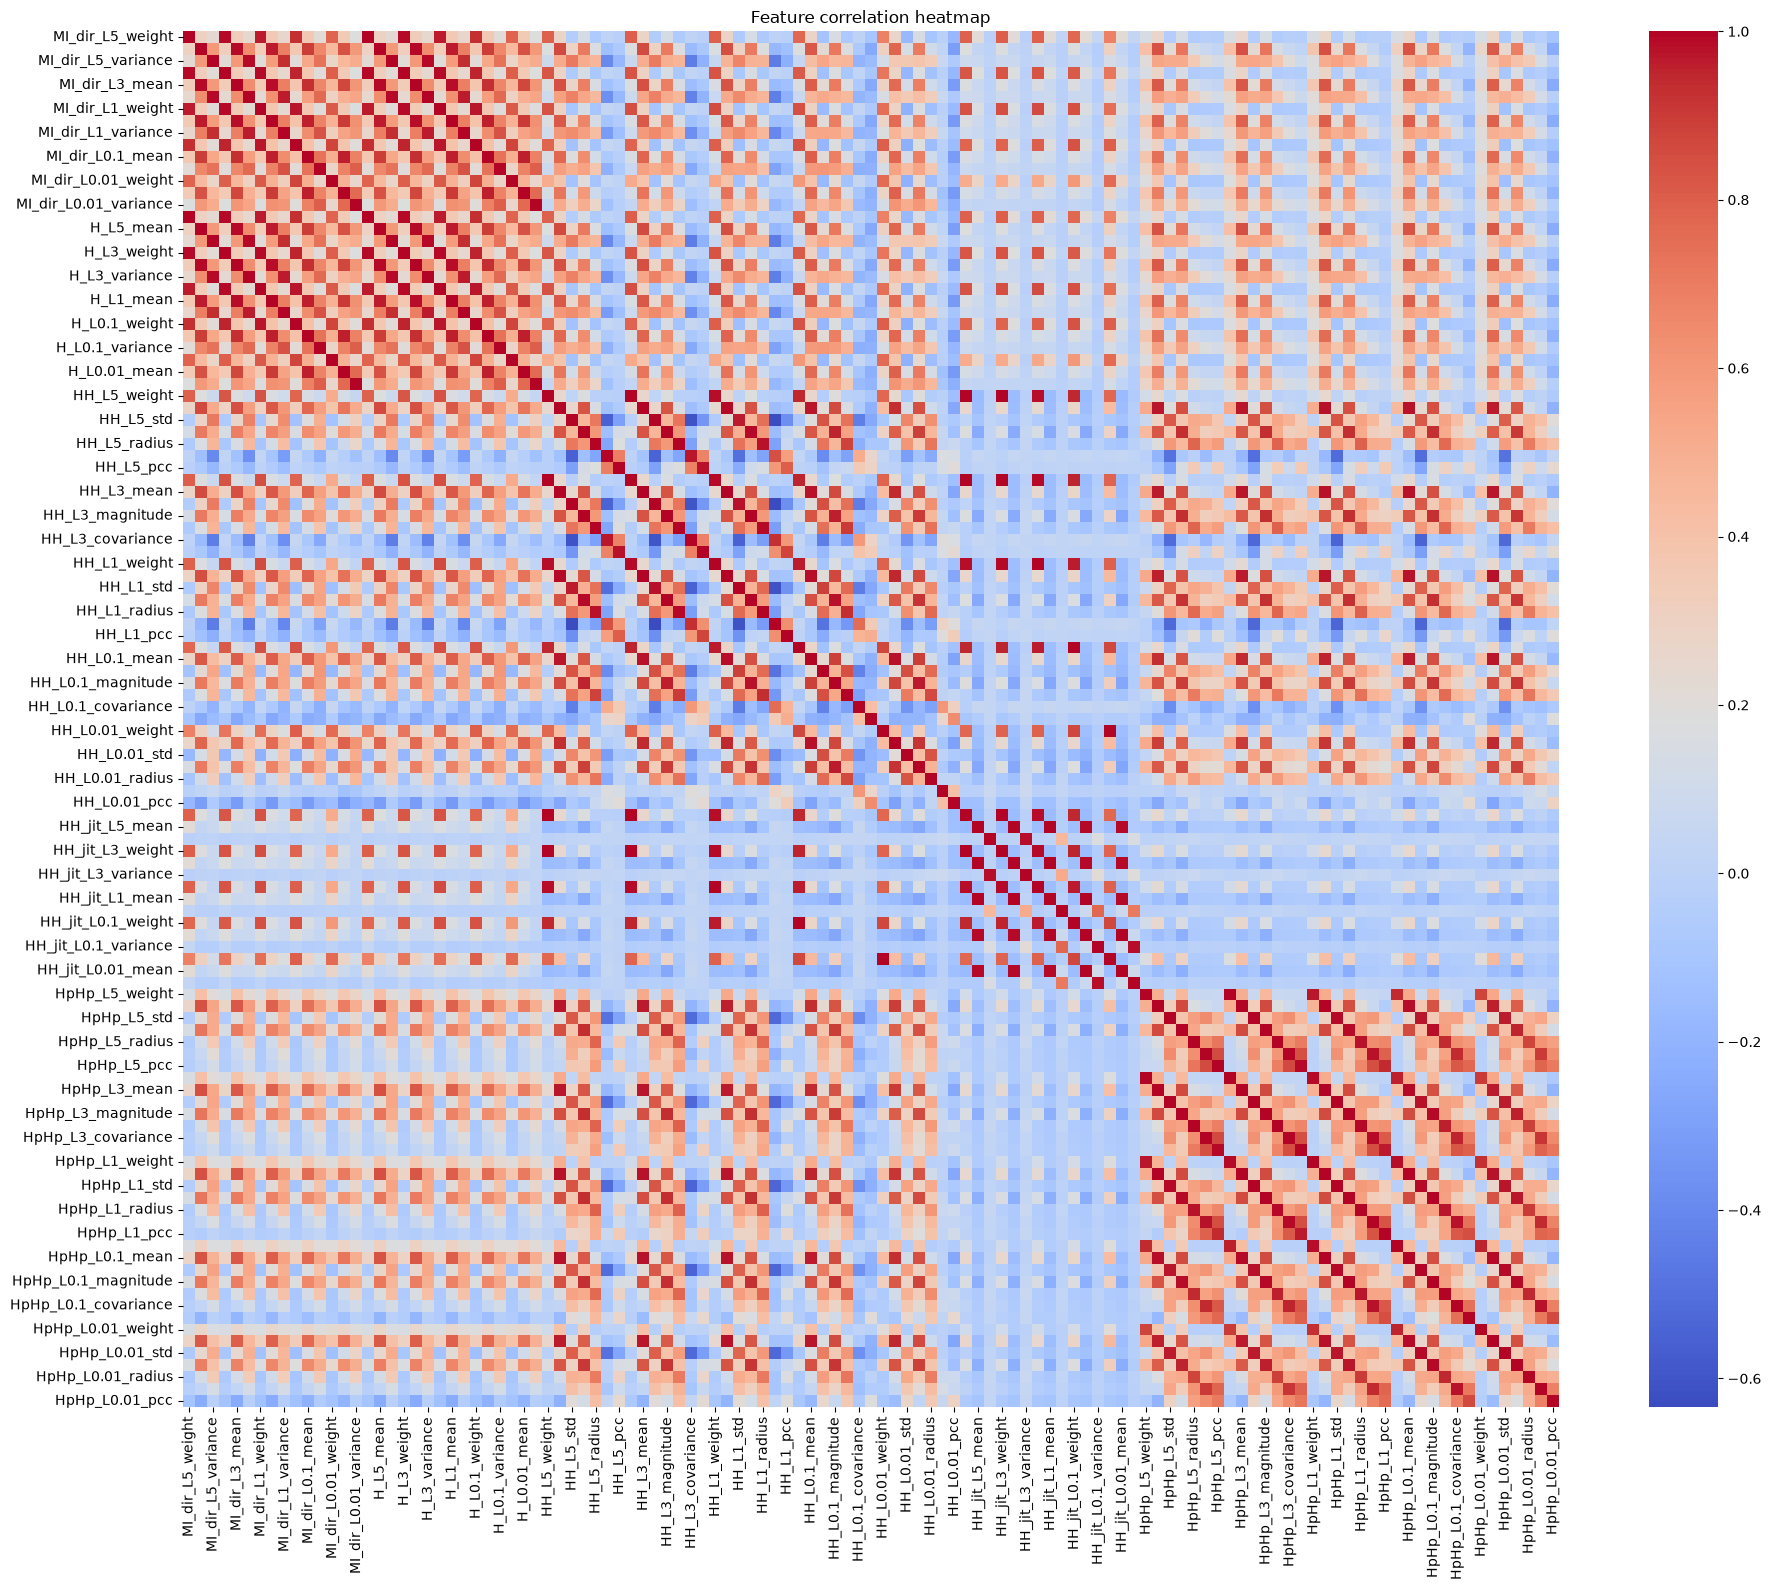

In [5]:
# Compute the Pearson correlation matrix across all feature columns
correlation_matrix = df[feature_columns].corr()

# Plot the correlation matrix as a heatmap
figure, axis = plt.subplots(figsize=(20, 16))
sns.heatmap(correlation_matrix, cmap="coolwarm", square=True, ax=axis)
axis.set_title("Feature correlation heatmap")
figure.tight_layout()
figure.savefig(Path(config.FIGURE_DIRECTORY) / "eda_correlation_heatmap.png")

In [6]:
# Keep only the upper triangle and exclude the diagonal to avoid duplicate pairs
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# List every feature pair more correlated than the set threshold
stacked_pairs = upper_triangle.stack()
high_correlation_pairs = (
    stacked_pairs[stacked_pairs.abs() > config.CORRELATION_THRESHOLD]
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    .reindex(columns=["feature_1", "feature_2", "correlation"])
)
high_correlation_pairs = high_correlation_pairs.reindex(high_correlation_pairs["correlation"].abs().sort_values(ascending=False).index)
print(f"Feature pairs above the correlation threshold: {len(high_correlation_pairs)}")
high_correlation_pairs

Feature pairs above the correlation threshold: 184


,feature_1,feature_2,correlation
84,HH_L3_weight,HH_jit_L3_weight,1.000000
117,HH_L0.01_weight,HH_jit_L0.01_weight,1.000000
61,HH_L5_weight,HH_jit_L5_weight,1.000000
101,HH_L1_weight,HH_jit_L1_weight,1.000000
112,HH_L0.1_weight,HH_jit_L0.1_weight,1.000000
...,...,...,...
86,HH_L3_weight,HH_jit_L0.1_weight,0.955309
168,HpHp_L3_covariance,HpHp_L0.1_covariance,0.953415
148,HpHp_L5_magnitude,HpHp_L0.01_magnitude,0.953212
179,HpHp_L0.1_weight,HpHp_L0.01_weight,0.953161


The heatmap shows blocks of five highly correlated features along the diagonal: each block is the same statistic (for example, `MI_dir` or `HH_jit`) measured over the five time windows (`L5`, `L3`, `L1`, `L0.1`, `L0.01`). The printed pair count confirms this redundancy, and columns that provide no additional information will be removed at the feature engineering stage.

## Compare benign and attack traffic feature by feature

One representative feature is chosen from each of the five feature families. All are from the same time window and the same underlying statistic to ensure that every feature is measured the same way before comparing them. Each is plotted as a boxplot split by label.

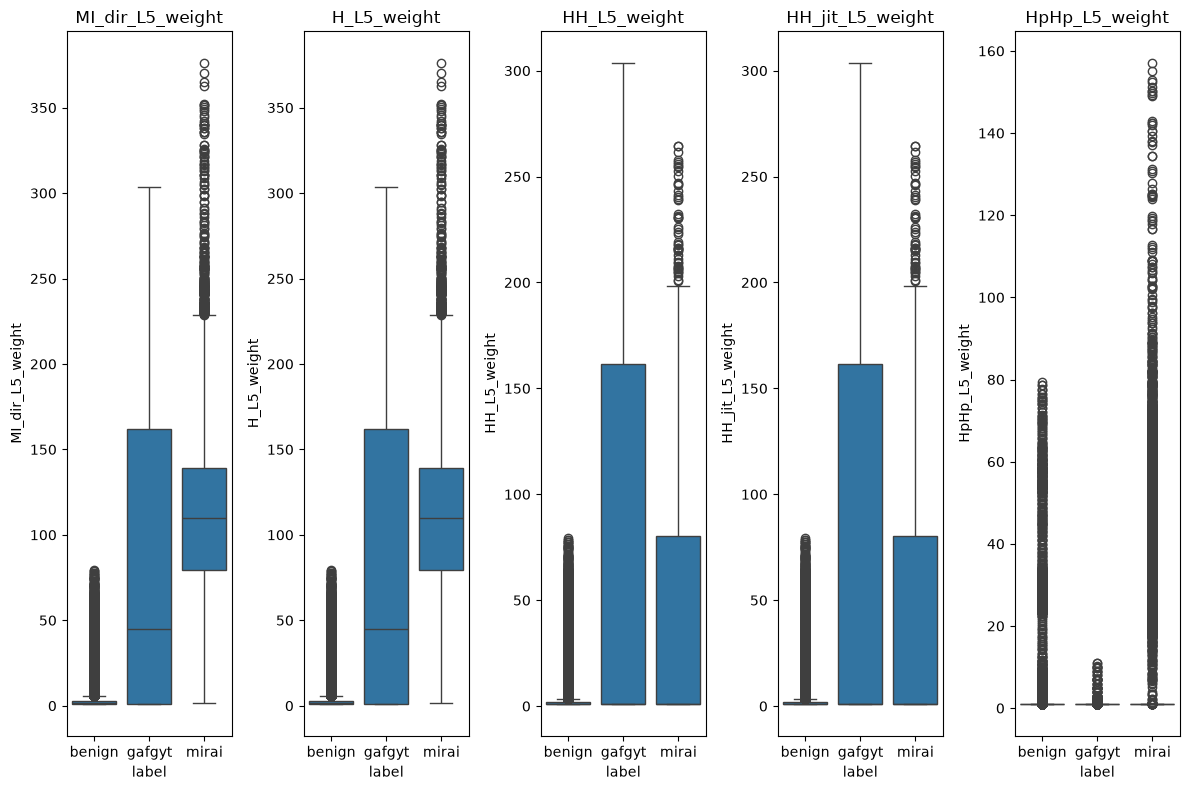

In [7]:
# One representative feature per feature family (same time window and statistic)
representative_features = ["MI_dir_L5_weight", "H_L5_weight", "HH_L5_weight", "HH_jit_L5_weight", "HpHp_L5_weight"]

# Plot a boxplot of each representative feature, split by label
figure, axes = plt.subplots(1, len(representative_features), figsize=(12, 8))
for axis, feature in zip(axes, representative_features):
    sns.boxplot(data=df, x="label", y=feature, ax=axis)
    axis.set_title(feature)
figure.tight_layout()
figure.savefig(Path(config.FIGURE_DIRECTORY) / "eda_boxplots_benign_versus_attack.png")

Attack traffic generally shows a much wider spread and larger outliers than benign traffic in these weight features, which track how much recent traffic matches a pattern and are driven up by flooding. However, this is not consistent across all features as gafgyt's HpHp_L5_weight is tighter than benign. Overall, benign traffic stays tightly clustered at low values throughout all features.

## Project each device's traffic into two dimensions

A 2D t-SNE projection is used to allow us to check by eye, whether benign and attack traffic look separable. t-SNE is chosen over PCA because it is designed to reveal cluster structure instead of preserving global linear variance, and it has no `transform` method. Hence, there is no fitted object that can be mistaken for something reusable later.

There are too many rows for each device for t-SNE to run on directly. Thus, a small stratified sample is drawn per device first. A `StandardScaler` is fit on that sample only, purely for this plot. The scaler and the t-SNE embedding are not saved.

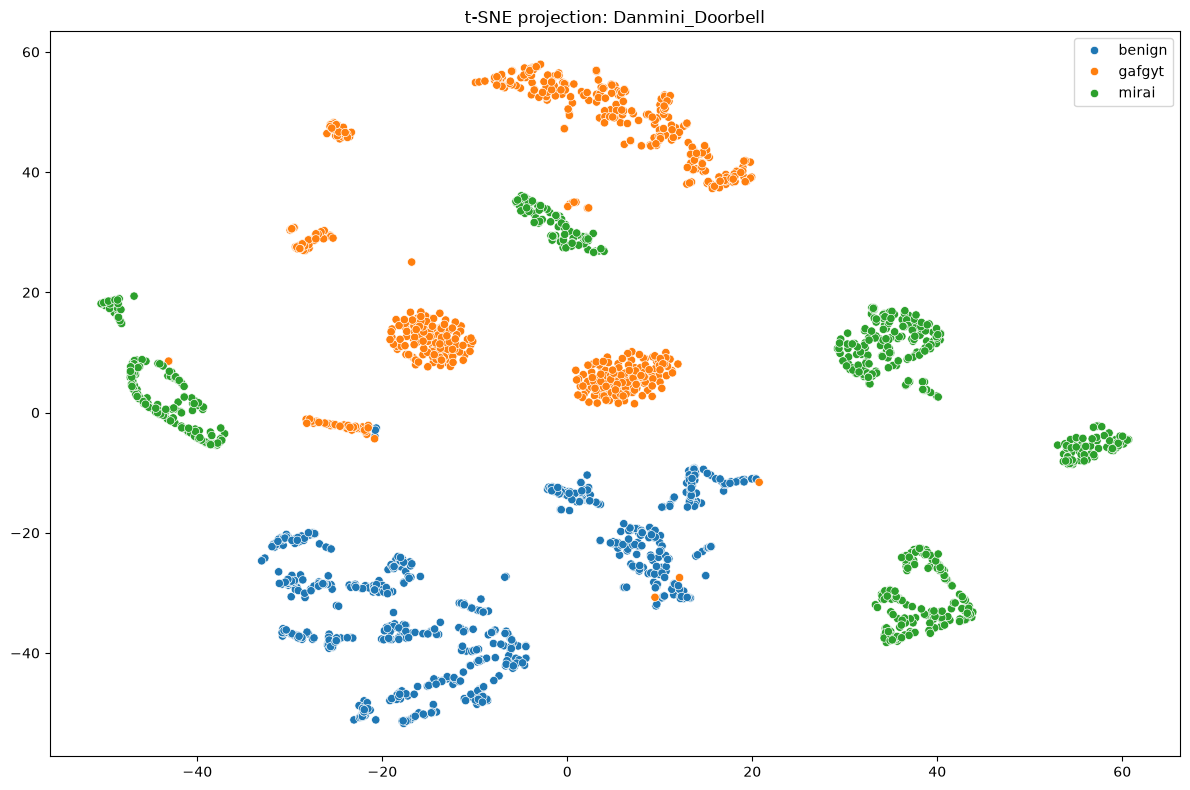

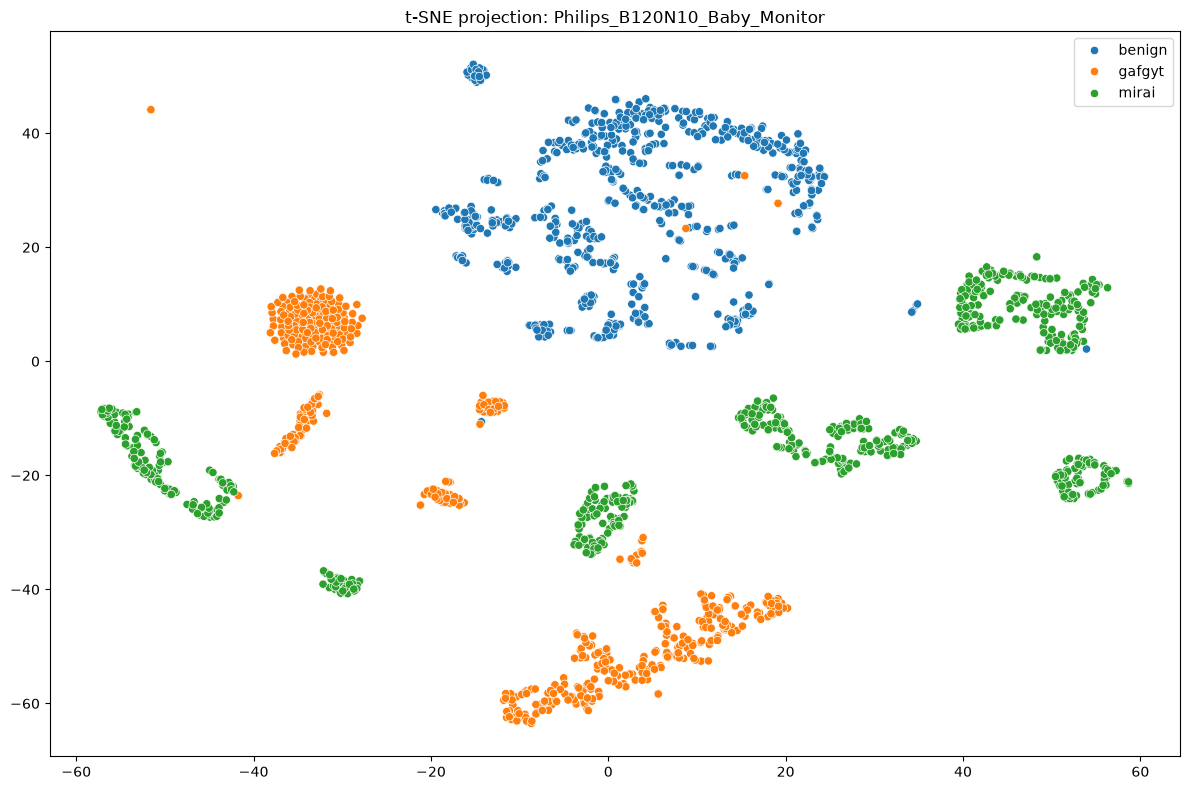

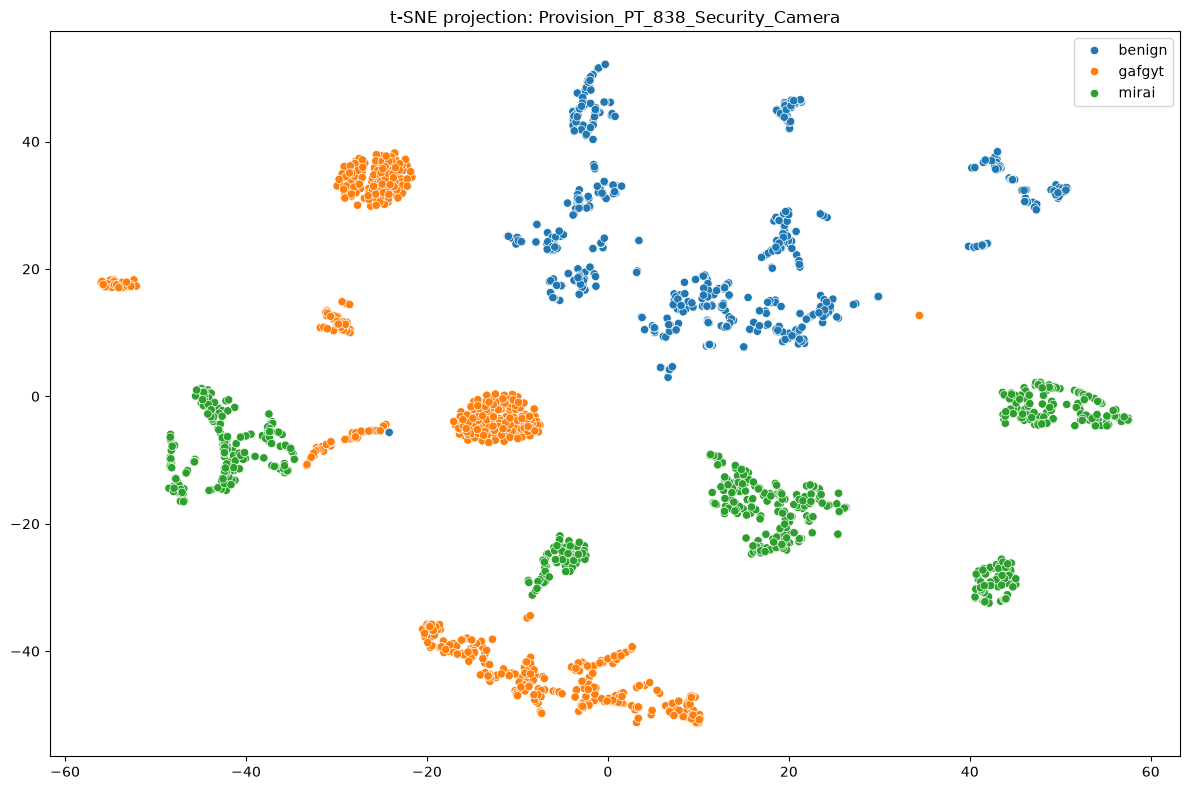

In [8]:
# Small stratified sample per device capped per label to allow t-SNE to run quickly
projection_sample_size_per_label = 700
for device_name in config.CHOSEN_DEVICES:
    device_df = df[df["device"] == device_name]
    sample = pd.concat([label_group.sample(n=min(len(label_group), projection_sample_size_per_label), random_state=config.RANDOM_SEED) for _, label_group in device_df.groupby("label")])

    # Standardise the sample locally and fit a fresh 2D t-SNE embedding
    scaled_features = StandardScaler().fit_transform(sample[feature_columns])
    embedding = TSNE(n_components=2, random_state=config.RANDOM_SEED).fit_transform(scaled_features)

    # Plot the embedding coloured by label, save one figure per device, and display it inline
    figure, axis = plt.subplots(figsize=(12, 8))
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=sample["label"].values, ax=axis)
    axis.set_title(f"t-SNE projection: {device_name}")
    figure.tight_layout()
    figure.savefig(Path(config.FIGURE_DIRECTORY) / f"eda_projection_{device_name}.png")
    plt.show()
    plt.close(figure)

For each device, benign and attack traffic occupy largely separate regions with little overlap. Both mirai and gafgyt traffic form multiple small, tight clusters of their own, which are likely different attack subtypes. This separation suggests the unsupervised models trained in later notebooks have a reasonable chance of distinguishing attack traffic from benign traffic.